In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pycot.reports import CommitmentsOfTraders
import seaborn as sns

In [2]:
# 스타일 설정
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("pastel")

01-Apr-25 17:05:33 - Extracting data for the legacy_fut report type


첫 5개 계약: ['#2 HEATING OIL, NY HARBOR-ULSD - NEW YORK MERCANTILE EXCHANGE'
 '#2 HEATING OIL- NY HARBOR-ULSD - NEW YORK MERCANTILE EXCHANGE'
 '- CHICAGO MERCANTILE EXCHANGE'
 '1% FUEL OIL NWE CRACK SPR - NEW YORK MERCANTILE EXCHANGE'
 '1-MONTH LIBOR RATE - CHICAGO MERCANTILE EXCHANGE']
선택된 계약: #2 HEATING OIL, NY HARBOR-ULSD - NEW YORK MERCANTILE EXCHANGE


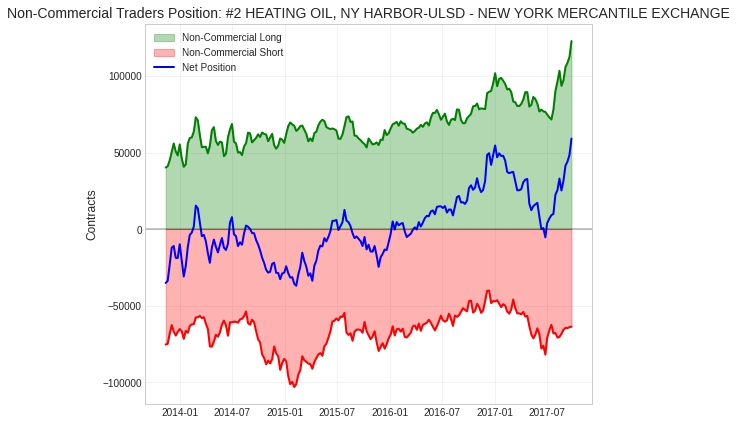

선택된 계약: #2 HEATING OIL- NY HARBOR-ULSD - NEW YORK MERCANTILE EXCHANGE


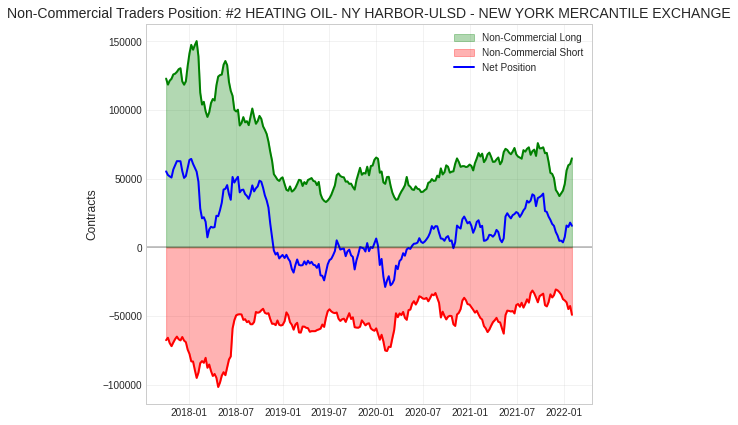

선택된 계약: - CHICAGO MERCANTILE EXCHANGE


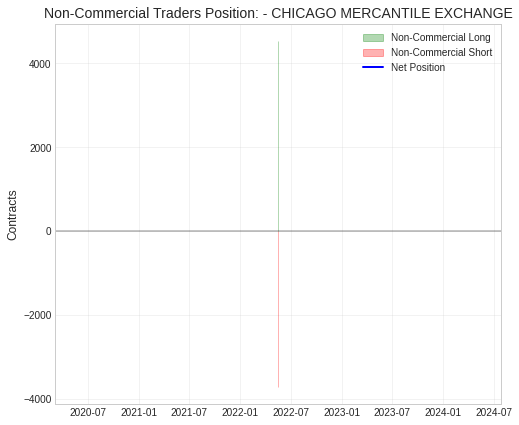

선택된 계약: 1% FUEL OIL NWE CRACK SPR - NEW YORK MERCANTILE EXCHANGE


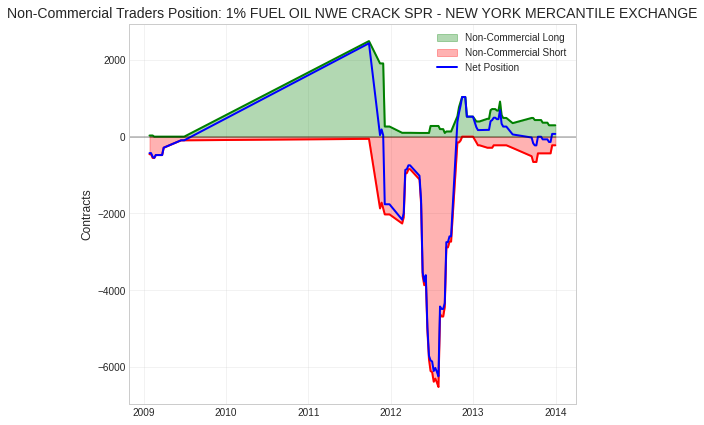

선택된 계약: 1-MONTH LIBOR RATE - CHICAGO MERCANTILE EXCHANGE


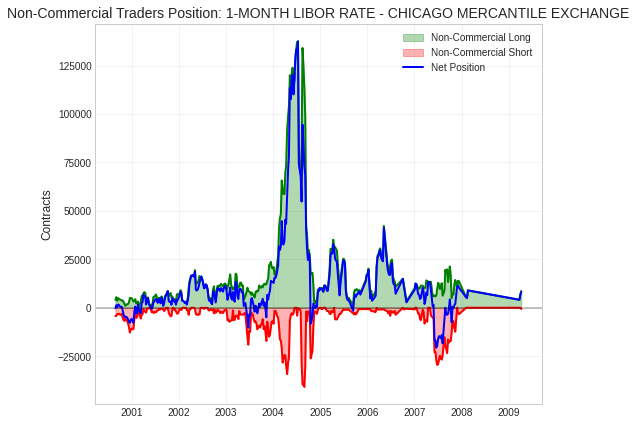

선택된 계약: 1-MONTH LIBOR RATE - INTERNATIONAL MONETARY MARKET


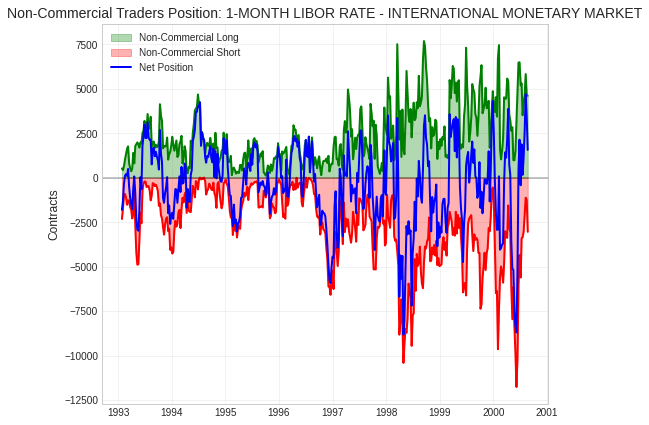

선택된 계약: 1-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE


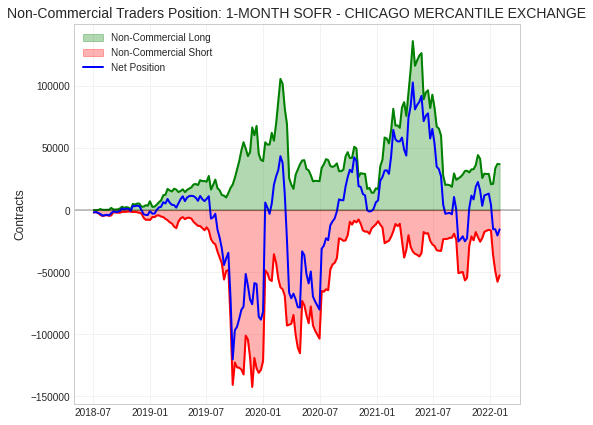

선택된 계약: 10 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE


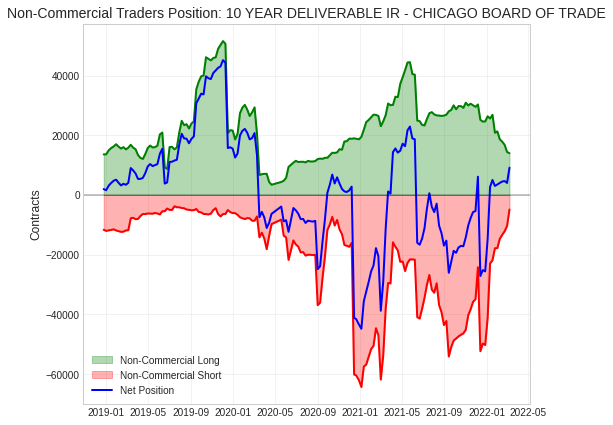

선택된 계약: 10 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF TRADE


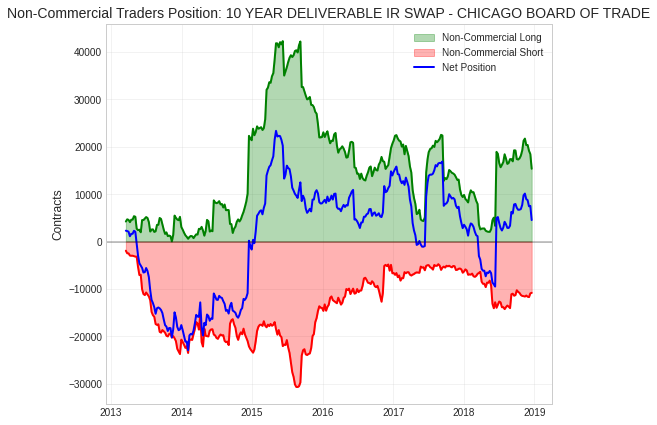

선택된 계약: 10 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE


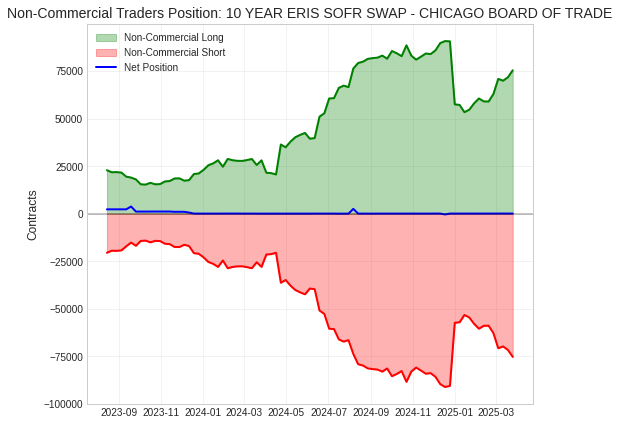

In [3]:
# legacy_fut 보고서 타입으로 COT 인스턴스 생성
cot = CommitmentsOfTraders(report_type="legacy_fut")

# 사용 가능한 계약 목록 확인 (첫 번째 실행 시 데이터를 다운로드하므로 시간이 걸릴 수 있음)
available_contracts = cot.list_available_contracts()
print(f"첫 5개 계약: {available_contracts[:5]}")

# available_contracts 중에서 10개 랜덤 샘플링해서 시각화
target_contracts = available_contracts[:10]
for i in range(len(target_contracts)):

    selected_contract = target_contracts[i]
    print(f"선택된 계약: {selected_contract}")

    # 선택한 계약의 데이터 가져오기
    df = cot.report(selected_contract)

    # 시각화 준비
    plt.figure(figsize=(8, 7))

    # 비상업 트레이더 포지션 시각화
    plt.subplot(1, 1, 1)
    plt.fill_between(
        df.index,
        df["Noncommercial Long"],
        color="green",
        alpha=0.3,
        label="Non-Commercial Long",
    )
    plt.fill_between(
        df.index,
        df["Noncommercial Short"],
        color="red",
        alpha=0.3,
        label="Non-Commercial Short",
    )
    plt.plot(df.index, df["Noncommercial Long"], color="green", linewidth=2)
    plt.plot(df.index, df["Noncommercial Short"], color="red", linewidth=2)
    plt.plot(
        df.index,
        df["Net Position, Large Spec"],
        color="blue",
        linewidth=2,
        label="Net Position",
    )
    plt.axhline(y=0, color="black", linestyle="-", alpha=0.3)
    plt.title(f"Non-Commercial Traders Position: {selected_contract}", fontsize=14)
    plt.ylabel("Contracts", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()